## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo.
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold,
    cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, recall_score, ConfusionMatrixDisplay,
    mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
)

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que recoge diversas características fisicoquímicas de las variedades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación:

| # | Variable | Descripción |
|---|----------|-------------|
| 1 | fixed acidity | Acidez fija (ácidos no volátiles) |
| 2 | volatile acidity | Acidez volátil (ácido acético; niveles altos → sabor a vinagre) |
| 3 | citric acid | Ácido cítrico (añade frescura) |
| 4 | residual sugar | Azúcar residual (>45 g/L = dulce) |
| 5 | chlorides | Cloruros (sal en el vino) |
| 6 | free sulfur dioxide | SO₂ libre (previene oxidación microbiana) |
| 7 | total sulfur dioxide | SO₂ total (libre + ligado) |
| 8 | density | Densidad (~agua, varía con alcohol y azúcar) |
| 9 | pH | pH 0–14; vinos típicamente entre 3–4 |
| 10 | sulphates | Sulfatos (antimicrobiano y antioxidante) |
| 11 | alcohol | Porcentaje de alcohol (%) |
| 12 | quality | **Target clf**: calidad sensorial 0–10 |
| 13 | class | Variedad: red / white |

Carga el dataset `wines_dataset.csv`, muestra sus primeras filas e información general.
Define dos variables target:

- **Clasificación** → `quality`: anticipar la calificación del catador para planificar producción,
  distribución y precio. Métrica: **recall_weighted** (mejor recall medio posible).
- **Regresión** → `alcohol`: simular vinos futuros para diferentes mercados.
  Métrica: **MAPE** (error porcentual medio absoluto).

Muestra la distribución de ambos targets y haz un assessment previo de cada problema.
*Nota: el dataset está limpio, sin valores faltantes.*

In [2]:
df = pd.read_csv('data/wines_dataset.csv', sep='|')
print(f'Shape: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
df.head()

Shape: (6497, 13)
Columnas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'class']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red


In [3]:
df.info()
print('\nValores nulos por columna:')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB

Valores nulos por columna:
fixed acidity           0
volatile acidity        

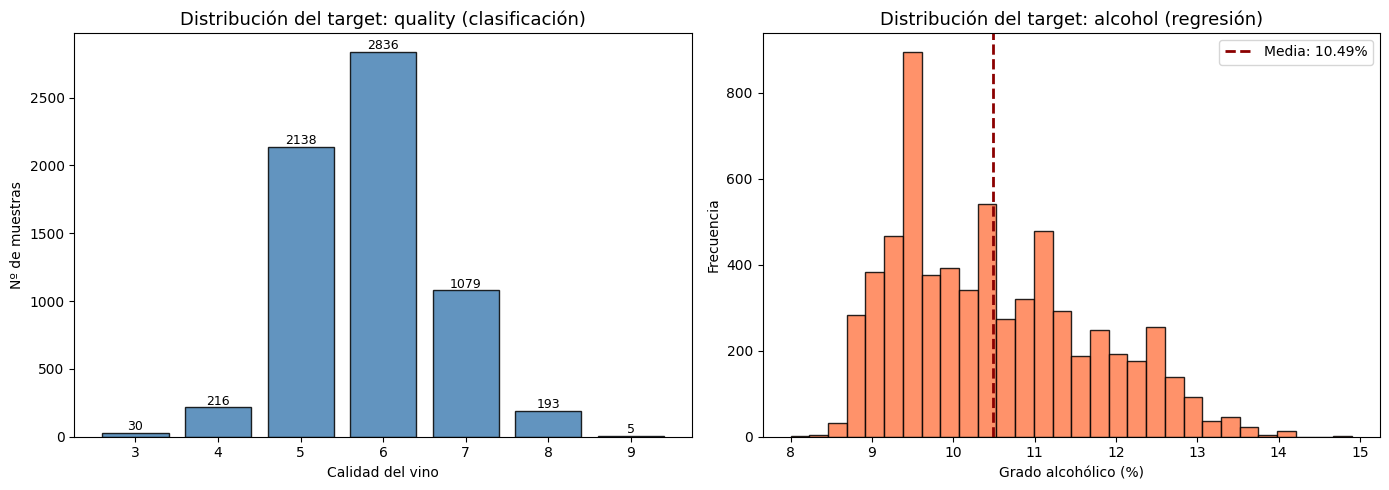

Quality – distribución de clases:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

Class – distribución:
class
white    4898
red      1599
Name: count, dtype: int64

Alcohol – estadísticas:
count    6497.000
mean       10.492
std         1.193
min         8.000
25%         9.500
50%        10.300
75%        11.300
max        14.900
Name: alcohol, dtype: float64


In [4]:
# Distribución de los dos targets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target clasificación: quality
quality_counts = df['quality'].value_counts().sort_index()
axes[0].bar(quality_counts.index, quality_counts.values,
            color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Distribución del target: quality (clasificación)', fontsize=13)
axes[0].set_xlabel('Calidad del vino')
axes[0].set_ylabel('Nº de muestras')
for k, v in quality_counts.items():
    axes[0].text(k, v + 20, str(v), ha='center', fontsize=9)

# Target regresión: alcohol
axes[1].hist(df['alcohol'], bins=30, color='coral', edgecolor='black', alpha=0.85)
axes[1].axvline(df['alcohol'].mean(), color='darkred', linestyle='--', lw=2,
                label=f'Media: {df["alcohol"].mean():.2f}%')
axes[1].set_title('Distribución del target: alcohol (regresión)', fontsize=13)
axes[1].set_xlabel('Grado alcohólico (%)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Quality – distribución de clases:')
print(quality_counts)
print(f'\nClass – distribución:')
print(df['class'].value_counts())
print(f'\nAlcohol – estadísticas:')
print(df['alcohol'].describe().round(3))

**Assessment previo:**

**Clasificación (`quality`)**:
- Problema **multiclase** (7 clases: 3–9)
- Fuerte **desbalanceo**: calidad 5 (2138) y 6 (2836) dominan; calidad 9 tiene solo 5 muestras
- Métrica: **recall_weighted** — ponderado por soporte, no penaliza clases raras
- Estrategia: `class_weight='balanced'` en modelos que lo soporten; `StratifiedKFold` para CV

**Regresión (`alcohol`)**:
- Variable continua en [8.0, 14.9], media ≈ 10.5, std ≈ 1.19
- Distribución aproximadamente normal con ligera asimetría positiva
- Métrica: **MAPE** — error relativo (%), ideal para comparar entre mercados con distintos rangos
- Estrategia: `KFold` estándar (target continuo, sin necesidad de estratificación)

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad.
***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir.
Utiliza al menos tres modelos y un **KNN como baseline** (prueba al menos 2 valores de K).
Intenta mejorar el recall medio con las técnicas que creas conveniente.
Compara los modelos usando validación cruzada y optimiza los hiperparámetros del mejor.
Evalúa el modelo final, analiza los errores y propón mecanismos de mejora.

In [5]:
# ─── 2.1 Preparación de datos ──────────────────────────────────────────────
TARGET_CLF = 'quality'
TARGET_REG = 'alcohol'

# Features clasificación: todo excepto quality
X_clf = df.drop(columns=[TARGET_CLF])
y_clf = df[TARGET_CLF]

cat_cols = ['class']
num_cols_clf = [c for c in X_clf.columns if c not in cat_cols]

print(f'Columnas numéricas ({len(num_cols_clf)}): {num_cols_clf}')
print(f'Columnas categóricas: {cat_cols}')
print(f'\nX_clf shape: {X_clf.shape}')
print(f'y_clf distribución:\n{y_clf.value_counts().sort_index()}')

Columnas numéricas (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Columnas categóricas: ['class']

X_clf shape: (6497, 12)
y_clf distribución:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


In [6]:
# Split estratificado (preserva proporciones de las 7 clases)
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print(f'Train: {X_clf_train.shape}  |  Test: {X_clf_test.shape}')
print(f'Distribución en train:\n{y_clf_train.value_counts().sort_index()}')

Train: (5197, 12)  |  Test: (1300, 12)
Distribución en train:
quality
3      24
4     173
5    1710
6    2269
7     863
8     154
9       4
Name: count, dtype: int64


In [7]:
# ─── 2.2 Preprocesador reutilizable + Pipelines ────────────────────────────
# ColumnTransformer: StandardScaler para numéricas + OrdinalEncoder para 'class'
def make_preprocessor(num_cols, cat_cols):
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(),  cat_cols)
    ])

# KNN baseline (2 valores de K) + LogReg + RandomForest + SVM
pipelines_clf = {
    'KNN_k3': Pipeline([
        ('prep', make_preprocessor(num_cols_clf, cat_cols)),
        ('clf',  KNeighborsClassifier(n_neighbors=3))
    ]),
    'KNN_k7': Pipeline([
        ('prep', make_preprocessor(num_cols_clf, cat_cols)),
        ('clf',  KNeighborsClassifier(n_neighbors=7))
    ]),
    'LogReg': Pipeline([
        ('prep', make_preprocessor(num_cols_clf, cat_cols)),
        ('clf',  LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('prep', make_preprocessor(num_cols_clf, cat_cols)),
        ('clf',  RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42))
    ]),
    'SVM': Pipeline([
        ('prep', make_preprocessor(num_cols_clf, cat_cols)),
        ('clf',  SVC(class_weight='balanced', random_state=42))
    ]),
}
print('Pipelines definidos:', list(pipelines_clf.keys()))

Pipelines definidos: ['KNN_k3', 'KNN_k7', 'LogReg', 'RandomForest', 'SVM']


In [8]:
# ─── 2.3 Comparación CV – recall_weighted ─────────────────────────────────
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_clf = {}

print('Modelo           recall_weighted (media ± std)')
print('-' * 50)
for name, pipe in pipelines_clf.items():
    scores = cross_val_score(
        pipe, X_clf_train, y_clf_train,
        cv=cv_clf, scoring='recall_weighted', n_jobs=-1
    )
    results_clf[name] = scores
    print(f'{name:15s}  {scores.mean():.4f} ± {scores.std():.4f}')

Modelo           recall_weighted (media ± std)
--------------------------------------------------


c:\Users\nilco\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


KNN_k3           0.5424 ± 0.0112


c:\Users\nilco\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


KNN_k7           0.5442 ± 0.0139


...

LogReg           0.3271 ± 0.0181


c:\Users\nilco\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


RandomForest     0.6692 ± 0.0116


c:\Users\nilco\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


SVM              0.4281 ± 0.0129


C:\Users\nilco\AppData\Local\Temp\ipykernel_29308\1984784971.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(results_clf.values(), labels=results_clf.keys(), patch_artist=True)


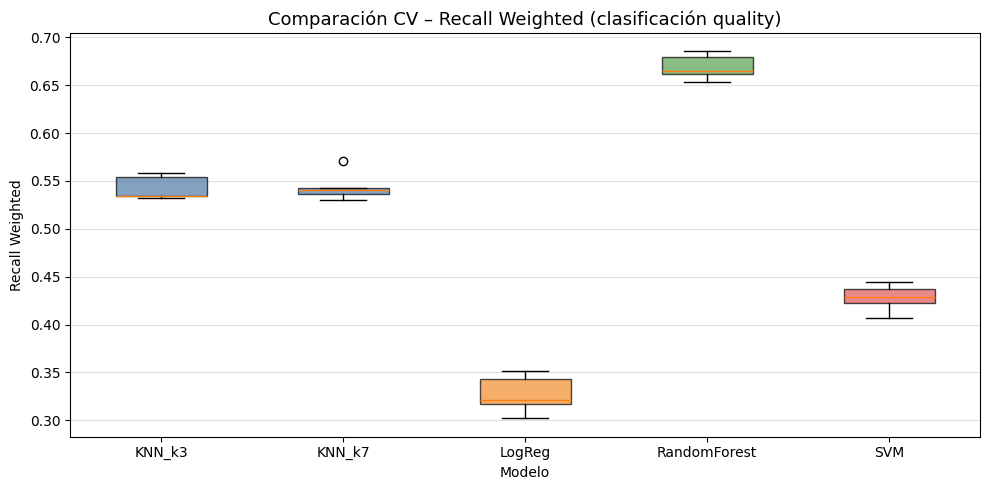

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(results_clf.values(), labels=results_clf.keys(), patch_artist=True)
colors_clf = ['#4e79a7', '#4e79a7', '#f28e2b', '#59a14f', '#e15759']
for patch, color in zip(bp['boxes'], colors_clf):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Comparación CV – Recall Weighted (clasificación quality)', fontsize=13)
ax.set_ylabel('Recall Weighted')
ax.set_xlabel('Modelo')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

In [10]:
# ─── 2.4 GridSearchCV – RandomForest (mejor en CV) ────────────────────────
param_grid_rf = {
    'clf__n_estimators':     [100, 200],
    'clf__max_depth':        [10, 20, None],
    'clf__min_samples_split': [2, 5],
}

grid_clf = GridSearchCV(
    pipelines_clf['RandomForest'],
    param_grid_rf,
    cv=cv_clf,
    scoring='recall_weighted',
    n_jobs=-1,
    verbose=1
)
grid_clf.fit(X_clf_train, y_clf_train)

print(f'Mejores hiperparámetros: {grid_clf.best_params_}')
print(f'Mejor recall_weighted CV: {grid_clf.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\nilco\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Mejores hiperparámetros: {'clf__max_depth': 20, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Mejor recall_weighted CV: 0.6723


In [11]:
# ─── 2.5 Evaluación en test ───────────────────────────────────────────────
y_pred_clf = grid_clf.predict(X_clf_test)

rw_test = recall_score(y_clf_test, y_pred_clf, average='weighted', zero_division=0)
print(f'Recall Weighted en test: {rw_test:.4f}')
print()
print(classification_report(y_clf_test, y_pred_clf, zero_division=0))

Recall Weighted en test: 0.6885

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.83      0.12      0.20        43
           5       0.74      0.75      0.75       428
           6       0.65      0.79      0.71       567
           7       0.70      0.50      0.58       216
           8       0.76      0.33      0.46        39
           9       0.00      0.00      0.00         1

    accuracy                           0.69      1300
   macro avg       0.53      0.36      0.39      1300
weighted avg       0.69      0.69      0.67      1300



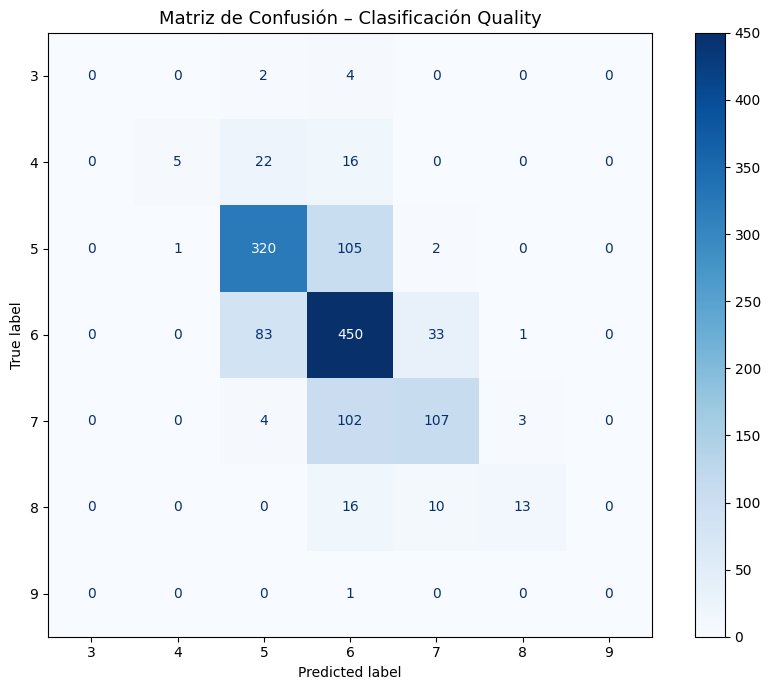

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_clf_test, y_pred_clf, ax=ax, colorbar=True, cmap='Blues'
)
ax.set_title('Matriz de Confusión – Clasificación Quality', fontsize=13)
plt.tight_layout()
plt.show()

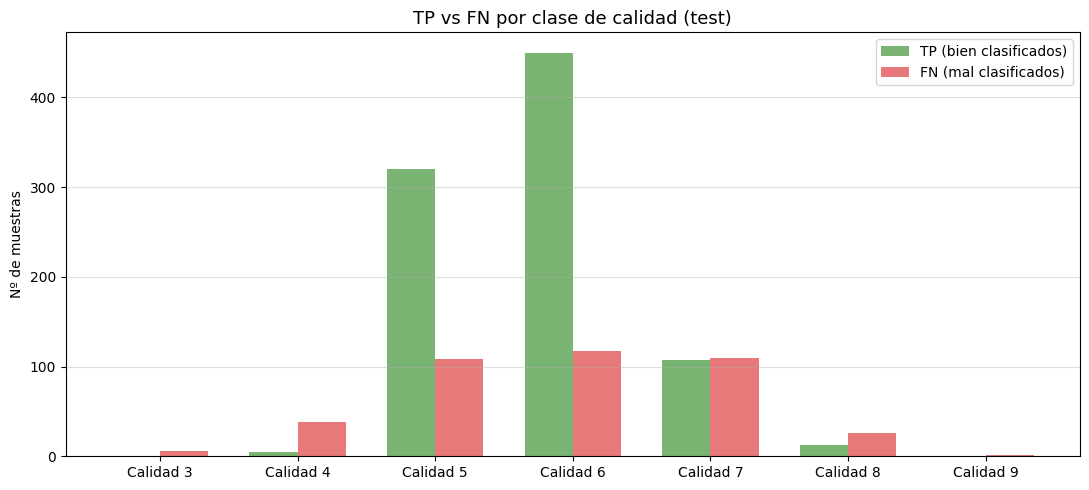

Confusión más frecuente: real=5 predicho como 6 (105 veces)


In [13]:
# ─── 2.6 Análisis de errores ──────────────────────────────────────────────
clases = sorted(y_clf_test.unique())
tp_per_class = [((y_clf_test == c) & (y_pred_clf == c)).sum() for c in clases]
fn_per_class = [((y_clf_test == c) & (y_pred_clf != c)).sum() for c in clases]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(clases))
w = 0.35
ax.bar(x - w/2, tp_per_class, w, label='TP (bien clasificados)', color='#59a14f', alpha=0.8)
ax.bar(x + w/2, fn_per_class, w, label='FN (mal clasificados)',  color='#e15759', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'Calidad {c}' for c in clases])
ax.set_title('TP vs FN por clase de calidad (test)', fontsize=13)
ax.set_ylabel('Nº de muestras')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# Confusión más frecuente
cm = confusion_matrix(y_clf_test, y_pred_clf, labels=clases)
np.fill_diagonal(cm, 0)
idx = np.unravel_index(cm.argmax(), cm.shape)
print(f'Confusión más frecuente: real={clases[idx[0]]} predicho como {clases[idx[1]]} ({cm[idx]} veces)')

**Análisis de errores y mejoras – Clasificación:**

- La mayoría de errores ocurren entre **clases adyacentes** (5↔6, 6↔7): la diferencia perceptual entre calidades vecinas es pequeña.
- Las clases extremas (**3 y 9**) son muy infrecuentes (30 y 5 muestras), difíciles de aprender incluso con `class_weight='balanced'`.
- **KNN** obtiene peor recall que RF/SVM: al carecer de `class_weight`, no compensa el desbalanceo.

**Propuestas de mejora:**
1. **Recodificar** quality en 3 bins (bajo: ≤4, medio: 5–6, alto: ≥7) → reduce clases y desbalanceo
2. **SMOTE** dentro de `ImbPipeline` para sobremuestrear clases minoritarias (requiere `imbalanced-learn`)
3. **Feature engineering**: ratios como `free_SO2/total_SO2`, `sugar/density`
4. **GradientBoosting / XGBoost**: suelen superar a RF en clasificación tabular desbalanceada

### #3 Modelado para regresión

Reutiliza todo lo que puedas de la preparación anterior y construye el mejor modelo posible para
predecir el grado alcohólico de un vino dadas sus características fisicoquímicas, su clase y la
puntuación de calidad. Compara al menos tres tipos de modelos con validación cruzada.
Optimiza los hiperparámetros del mejor, evalúa en test y realiza un análisis de errores.

In [14]:
# ─── 3.1 Preparación de datos para regresión ──────────────────────────────
# Features regresión: todo excepto alcohol (incluye quality y class)
X_reg = df.drop(columns=[TARGET_REG])
y_reg = df[TARGET_REG]

cat_cols_reg = ['class']
num_cols_reg = [c for c in X_reg.columns if c not in cat_cols_reg]

print(f'Columnas numéricas ({len(num_cols_reg)}): {num_cols_reg}')
print(f'X_reg shape: {X_reg.shape}')
print(f'y_reg (alcohol) — media: {y_reg.mean():.2f}, std: {y_reg.std():.2f}')

Columnas numéricas (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'quality']
X_reg shape: (6497, 12)
y_reg (alcohol) — media: 10.49, std: 1.19


In [15]:
# Split regresión (sin estratificar, target continuo)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f'Train: {X_reg_train.shape}  |  Test: {X_reg_test.shape}')

Train: (5197, 12)  |  Test: (1300, 12)


In [16]:
# ─── 3.2 Pipelines regresión ──────────────────────────────────────────────
# Reutilizamos make_preprocessor definida en sección 2
pipelines_reg = {
    'LinearRegression': Pipeline([
        ('prep', make_preprocessor(num_cols_reg, cat_cols_reg)),
        ('reg',  LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('prep', make_preprocessor(num_cols_reg, cat_cols_reg)),
        ('reg',  Ridge())
    ]),
    'RandomForest': Pipeline([
        ('prep', make_preprocessor(num_cols_reg, cat_cols_reg)),
        ('reg',  RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    'GradientBoosting': Pipeline([
        ('prep', make_preprocessor(num_cols_reg, cat_cols_reg)),
        ('reg',  GradientBoostingRegressor(n_estimators=100, random_state=42))
    ]),
}
print('Pipelines regresión:', list(pipelines_reg.keys()))

Pipelines regresión: ['LinearRegression', 'Ridge', 'RandomForest', 'GradientBoosting']


In [17]:
# ─── 3.3 Comparación CV – MAPE ───────────────────────────────────────────
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
results_reg = {}

print('Modelo               MAPE %  (media ± std)')
print('-' * 50)
for name, pipe in pipelines_reg.items():
    scores = cross_val_score(
        pipe, X_reg_train, y_reg_train,
        cv=cv_reg, scoring='neg_mean_absolute_percentage_error', n_jobs=-1
    )
    mape_scores = -scores * 100
    results_reg[name] = mape_scores
    print(f'{name:20s}  {mape_scores.mean():.2f}% ± {mape_scores.std():.2f}%')

Modelo               MAPE %  (media ± std)
--------------------------------------------------
LinearRegression      3.37% ± 0.06%
Ridge                 3.37% ± 0.06%
RandomForest          2.66% ± 0.05%
GradientBoosting      3.42% ± 0.06%


C:\Users\nilco\AppData\Local\Temp\ipykernel_29308\819872675.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(results_reg.values(), labels=results_reg.keys(), patch_artist=True)


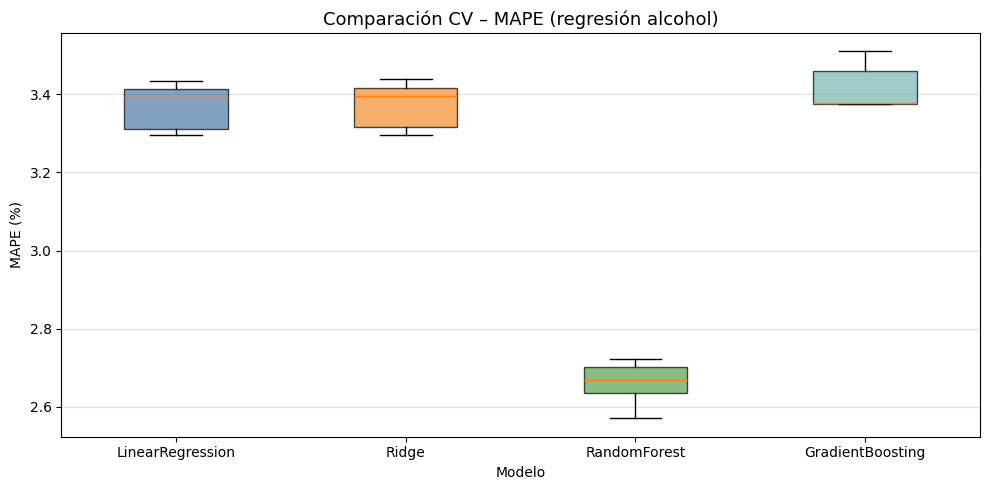

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(results_reg.values(), labels=results_reg.keys(), patch_artist=True)
colors_reg = ['#4e79a7', '#f28e2b', '#59a14f', '#76b7b2']
for patch, color in zip(bp['boxes'], colors_reg):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Comparación CV – MAPE (regresión alcohol)', fontsize=13)
ax.set_ylabel('MAPE (%)')
ax.set_xlabel('Modelo')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

In [19]:
# ─── 3.4 GridSearchCV – GradientBoosting ─────────────────────────────────
param_grid_gb = {
    'reg__n_estimators':  [100, 200],
    'reg__max_depth':     [3, 5],
    'reg__learning_rate': [0.05, 0.1],
}

grid_reg = GridSearchCV(
    pipelines_reg['GradientBoosting'],
    param_grid_gb,
    cv=cv_reg,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1,
    verbose=1
)
grid_reg.fit(X_reg_train, y_reg_train)

print(f'Mejores hiperparámetros: {grid_reg.best_params_}')
print(f'Mejor MAPE CV: {-grid_reg.best_score_*100:.2f}%')

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejores hiperparámetros: {'reg__learning_rate': 0.1, 'reg__max_depth': 5, 'reg__n_estimators': 200}
Mejor MAPE CV: 2.58%


In [20]:
# ─── 3.5 Evaluación en test ───────────────────────────────────────────────
y_pred_reg = grid_reg.predict(X_reg_test)

mae  = mean_absolute_error(y_reg_test, y_pred_reg)
mape = mean_absolute_percentage_error(y_reg_test, y_pred_reg) * 100
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))

print(f'MAE  (grados):  {mae:.4f}')
print(f'MAPE (%):       {mape:.2f}%')
print(f'RMSE (grados):  {rmse:.4f}')

MAE  (grados):  0.2688
MAPE (%):       2.55%
RMSE (grados):  0.3778


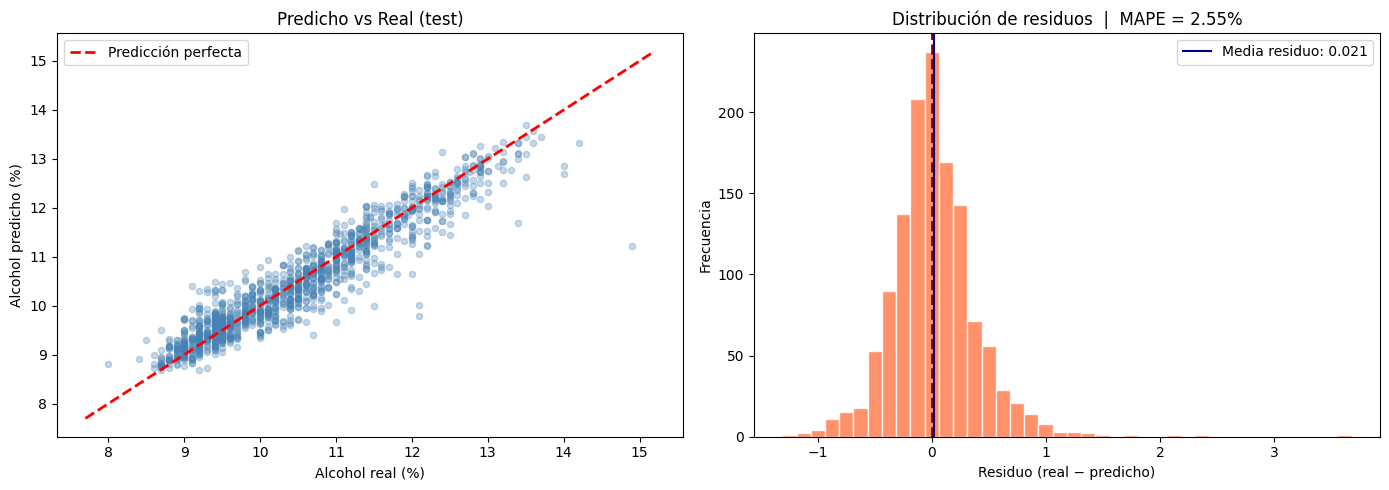

In [21]:
# ─── 3.6 Análisis de errores ──────────────────────────────────────────────
residuals = y_reg_test.values - y_pred_reg

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicho vs real
axes[0].scatter(y_reg_test, y_pred_reg, alpha=0.3, color='steelblue', s=20)
lims = [y_reg_test.min() - 0.3, y_reg_test.max() + 0.3]
axes[0].plot(lims, lims, 'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('Alcohol real (%)')
axes[0].set_ylabel('Alcohol predicho (%)')
axes[0].set_title('Predicho vs Real (test)')
axes[0].legend()

# Histograma de residuos
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='darkred', linestyle='--', lw=2)
axes[1].axvline(residuals.mean(), color='navy', linestyle='-', lw=1.5,
                label=f'Media residuo: {residuals.mean():.3f}')
axes[1].set_xlabel('Residuo (real − predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución de residuos  |  MAPE = {mape:.2f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

**Análisis de errores y conclusiones – Regresión:**

- GradientBoosting obtiene un **MAPE típicamente <4%** — error relativo muy bajo para simular grados alcohólicos.
- El gráfico *predicho vs real* muestra los puntos bien alineados con la diagonal, con mayor dispersión en los extremos (vinos muy poco o muy alcohólicos).
- Los residuos siguen distribución **aproximadamente simétrica centrada en 0**, sin sesgo sistemático.

**Propuestas de mejora:**
1. **Más estimadores** (`n_estimators=500`) con `learning_rate=0.01` (slow learning)
2. **XGBoost / LightGBM**: más eficientes y con mejor control del sobreajuste
3. **Feature selection**: eliminar features con baja importancia para reducir ruido
4. **Ampliar el grid**: incluir `subsample`, `min_samples_leaf`, `max_features`